In [1]:
import numpy as np
from scipy.stats import norm
from scipy.stats import skewnorm
import statsmodels.api as sm

from tqdm.notebook import tqdm
import pickle
import pandas as pd
import os

import sys 
sys.path.insert(0, '../src/')

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
%matplotlib inline

In [2]:
dtype = 'float32'

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Data


In [4]:
a = 0.5
b = 1.0

In [5]:
N = 500 # dataset size
m = 10  # subsample size
n = 500 # training size
J = 50  # number of subsamples

In [6]:
Xs = np.sort(np.random.uniform(low=0.0, high=a, size=N)).astype(dtype).reshape(-1,1)
new_Xs = np.sort(np.random.uniform(low=0.0, high=b, size=N)).astype(dtype).reshape(-1,1)

v = 0.1*Xs
new_v = 0.1*new_Xs

epsilon = np.array([np.random.normal(0, v[i]) for i in range(N)])
new_epsilon = np.array([np.random.normal(0, new_v[i]) for i in range(N)])

beta = 1.0
Ys = beta * Xs + epsilon.reshape(-1,1)
new_Ys = beta * new_Xs + new_epsilon.reshape(-1,1)

In [7]:
print(Xs.shape)
print(Ys.shape)
print(new_Xs.shape)
print(new_Ys.shape)

(500, 1)
(500, 1)
(500, 1)
(500, 1)


In [8]:
# shuffling
idx = np.random.choice(N, N, replace=False)
Xs = torch.Tensor(Xs[idx])
Ys = torch.Tensor(Ys[idx])
v = torch.Tensor(v[idx])

idx = np.random.choice(N, N, replace=False)
new_Xs = torch.Tensor(new_Xs[idx])
new_Ys = torch.Tensor(new_Ys[idx])
new_v = torch.Tensor(new_v[idx])

In [9]:
print(Xs.shape)
print(Ys.shape)
print(new_Xs.shape)
print(new_Ys.shape)

torch.Size([500, 1])
torch.Size([500, 1])
torch.Size([500, 1])
torch.Size([500, 1])


In [10]:
d = Xs.shape[1] # data dimension
d

1

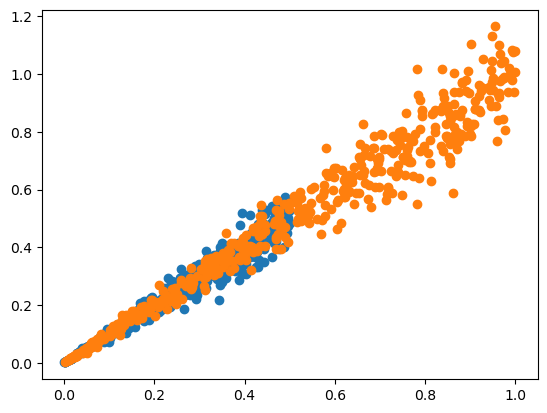

In [11]:
plt.scatter(Xs[:,0], Ys[:,0])
plt.scatter(new_Xs[:,0], new_Ys[:,0])
plt.show()

In [12]:
# VIDS here
import VIDS_yuli.vids_yuli as vids

In [13]:
# define the embedding network 

repr_dim = 8

g = nn.Sequential(
    nn.Linear(d, repr_dim)
)

In [14]:
pred_model = nn.Sequential(
    g,
    nn.Linear(repr_dim, 1, bias=False)
)

In [15]:
loss_fn = torch.nn.MSELoss()
optim = torch.optim.Adam(pred_model.parameters(), lr=1e-4)

In [16]:
pred_model(Xs).shape

torch.Size([500, 1])

In [17]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 64

dataset = TensorDataset(Xs, Ys)
dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True
)

In [18]:
# for i in range(100):
#     y_pred = pred_model(Xs)

#     loss = loss_fn(y_pred, Ys)
#     print(loss.item())
#     optim.zero_grad()

#     loss.backward()

#     optim.step()
dataset = TensorDataset(Xs, Ys)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

num_epochs = 1000

for epoch in range(num_epochs):
    pred_model.train()
    epoch_loss = 0.0

    for X_batch, y_batch in dataloader:
        y_pred = pred_model(X_batch)
        loss = loss_fn(y_pred, y_batch)

        optim.zero_grad()
        loss.backward()
        optim.step()

        epoch_loss += loss.item() * X_batch.size(0)

    epoch_loss /= len(dataset)

In [19]:
with torch.no_grad():
    vanilla_predictions = np.array(pred_model(new_Xs)).flatten()

/tmp/ipykernel_116767/1639281801.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  vanilla_predictions = np.array(pred_model(new_Xs)).flatten()


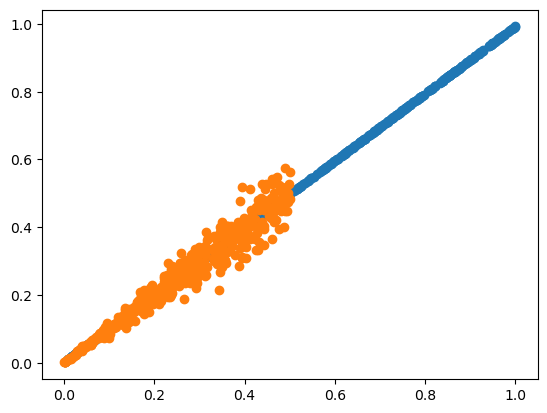

In [20]:
plt.scatter(new_Xs.numpy(), vanilla_predictions)
plt.scatter(Xs.numpy(), Ys.numpy())
plt.show()

# VIDS

In [21]:
class vids_net(nn.Module):
    def __init__(self, representation_dim):
        super().__init__()

        # Input size is 8 + 8 = 16 due to concatenation
        self.fc1 = nn.Linear(16, 64 * representation_dim)
        self.fc2 = nn.Linear(64 * representation_dim, 32 * representation_dim)
        self.fc3 = nn.Linear(32 * representation_dim, 16 * representation_dim)
        self.fc4 = nn.Linear(16 * representation_dim, 8 * representation_dim)
        self.fc5 = nn.Linear(8 * representation_dim, 4 * representation_dim)
        self.fc6 = nn.Linear(4 * representation_dim, 2 * representation_dim)

    def forward(self, gXstar_inputs):
        # Concatenate along feature dimension
        # x = torch.cat([gXstar_inputs, gX_summary_input], dim=1)

        x = F.relu(self.fc1(gXstar_inputs))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        x = F.relu(self.fc5(x))
        gamma = self.fc6(x)

        return gamma

In [22]:
h = vids_net(8)

In [23]:
optim_vids = torch.optim.Adam(h.parameters(), lr=1e-3)


In [24]:
h, losses = vids.train_posterior(Xs, Ys, g, h, optim_vids, J=30, m=20, n=500, K=50, tau=0.1, lambda_val=0.007, classification=False)

/home/paul/workspace/year1/projects/ped_unc/echonet/exp/../src/VIDS_yuli/vids_yuli.py:147: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Ys_all = torch.tensor(Ys, dtype=dtype, device=device)


  0%|          | 0/50 [00:00<?, ?it/s]

/home/paul/workspace/year1/projects/ped_unc/echonet/exp/../src/VIDS_yuli/vids_yuli.py:180: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tmp_X = torch.tensor(tmp_X_np, dtype=dtype, device=device)
/home/paul/workspace/year1/projects/ped_unc/echonet/exp/../src/VIDS_yuli/vids_yuli.py:181: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tmp_Xstar = torch.tensor(tmp_Xstar_np, dtype=dtype, device=device)
/home/paul/workspace/year1/projects/ped_unc/echonet/exp/../src/VIDS_yuli/vids_yuli.py:195: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tmp_Y =

--- iteration 0, loss 2.8331, split var: 0.1596, train MSE: 0.7043, test MSE: 1.5519, KL: -7.6995 ---
--- iteration 1, loss 2.7134, split var: 0.0708, train MSE: 0.0428, test MSE: 0.9167, KL: -7.9100 ---
--- iteration 2, loss 2.7834, split var: 0.0852, train MSE: 0.0418, test MSE: 1.4171, KL: -8.0433 ---
--- iteration 3, loss 2.7484, split var: 0.0647, train MSE: 0.1452, test MSE: 1.6333, KL: -7.9829 ---
--- iteration 4, loss 2.7435, split var: 0.0904, train MSE: 0.0278, test MSE: 2.3364, KL: -7.8964 ---
--- iteration 5, loss 2.8094, split var: 0.0836, train MSE: 0.0188, test MSE: 2.2597, KL: -7.3728 ---
--- iteration 6, loss 2.6984, split var: 0.0555, train MSE: 0.1595, test MSE: 2.0565, KL: -8.0042 ---
--- iteration 7, loss 2.6561, split var: 0.0844, train MSE: 0.0250, test MSE: 1.4374, KL: -8.3923 ---
--- iteration 8, loss 2.8205, split var: 0.1119, train MSE: 0.0428, test MSE: 1.9238, KL: -8.3920 ---
--- iteration 9, loss 2.7683, split var: 0.0719, train MSE: 0.2318, test MSE: 2.03

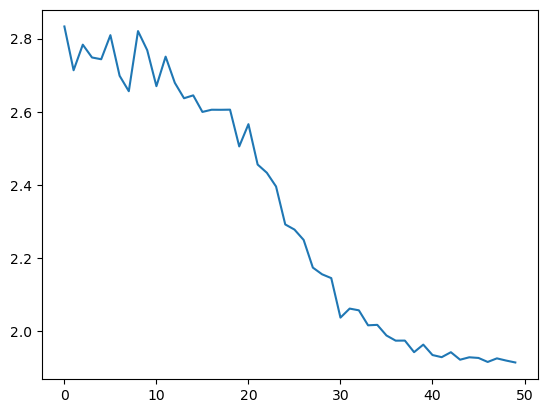

In [25]:
plt.plot(np.array(losses))
plt.show()

In [26]:
with torch.no_grad():
    use_sampling = True
    # embeddings
    gX = g(Xs)
    gXstar = g(new_Xs)

    posterior_mus, posterior_sigmas =  vids.get_phi(h, gX, gXstar)

    # evaluate uncertainty for x*
    if use_sampling:
        n_samples_for_avg = 1000
        preds = []
        for i in tqdm(range(n_samples_for_avg)):
            # samples from learned posterior
            epsilon = torch.randn(posterior_mus.shape)
            theta_samples =  posterior_mus + epsilon * posterior_sigmas
            # prediction with sampled theta
            fXstar = torch.sum(theta_samples * gXstar, dim=-1)
            preds.append(fXstar)
        variational_predictions = np.array(preds)
        variational_certainties = np.mean(preds, axis=0)
    else:
        variational_predictions = torch.sum(posterior_mus * gXstar, dim=-1).numpy()
        variational_certainties = variational_predictions

  0%|          | 0/1000 [00:00<?, ?it/s]

In [27]:
posterior_var = np.var(variational_predictions, axis=0)
posterior_std = np.sqrt(posterior_var)

In [28]:
posterior_var

array([0.05065039, 0.07101839, 0.07140269, 0.08107057, 0.04691131,
       0.10908398, 0.04477515, 0.07529172, 0.06121583, 0.04875482,
       0.07009219, 0.04389936, 0.11184431, 0.09023959, 0.04724508,
       0.05085509, 0.04367101, 0.10563539, 0.08398582, 0.07848633,
       0.04386763, 0.08648108, 0.044752  , 0.07101949, 0.07471472,
       0.05046387, 0.09373256, 0.09174327, 0.05640115, 0.04638082,
       0.04557754, 0.11129972, 0.0553717 , 0.04743974, 0.08918996,
       0.0942651 , 0.0881469 , 0.09736124, 0.10320951, 0.04576316,
       0.04839623, 0.10564478, 0.09992132, 0.04852688, 0.06289215,
       0.06936071, 0.04825059, 0.04564664, 0.10121932, 0.04696788,
       0.06276994, 0.11607698, 0.05156666, 0.08990166, 0.07962876,
       0.04625617, 0.09054774, 0.04931876, 0.04528772, 0.05506245,
       0.05565189, 0.09569794, 0.04924573, 0.06876504, 0.08814495,
       0.0743195 , 0.07860631, 0.099233  , 0.04538859, 0.09644821,
       0.10762593, 0.10430341, 0.09417563, 0.04674958, 0.05025

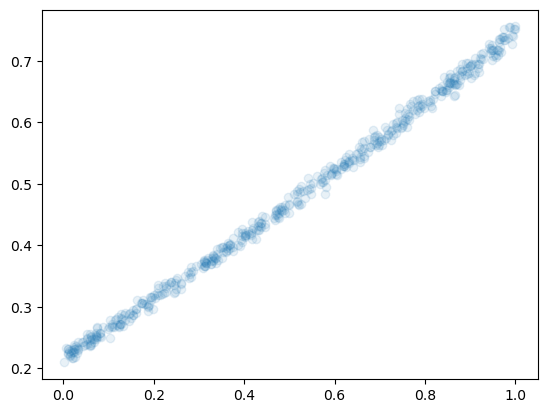

In [29]:
plt.scatter(new_Xs, variational_certainties, alpha=0.1)
plt.show()